In [1]:
from typing import TypedDict, List, Optional, Dict, Union, Any, Annotated, Sequence
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
# from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
import httpx
import os
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [3]:
class AgentState(TypedDict):
    """State of the agent, including the chat history and tool calls."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    flight_candidates: Sequence[Dict[str, Any]]
    selected_flight: Dict[str, Any]
    # hotel_candidates: Sequence[Dict[str, Any]]      # List of hotel search results
    # selected_hotel: Dict[str, Any]                  # Hotel confirmed by user
    # tool_output: Any                                # Output from the last tool (can be anything)
    agent_action: Union[str, Dict[str, Any]]        # Tool name or full action object from LLM


In [4]:
def search_location(location):
  """This function searches the source's and destination's airport ID for a given location using the Booking.com API. The first step when searching for flights."""

  url = "https://booking-com15.p.rapidapi.com/api/v1/flights/searchDestination"

  querystring = {"query":location}

  headers = {
    "x-rapidapi-key": os.getenv('x-rapidapi-key'),
    "x-rapidapi-host": "booking-com15.p.rapidapi.com"
  }
  try:
    response = httpx.get(url, headers=headers, params=querystring)
    response.raise_for_status()  # Raise an error for bad responses
    airport_id = response.json().get('data', [])
    
    if not airport_id:
        print("No destinations found for this query.")
        airport_details = []

        # Print all possible matches
    # for dest in airport_id:
    #     print(f"Name: {dest['name']}, ID: {dest['id']}, Country: {dest['country']}")
    #     return dest['id']
    airport_details = [dest["id"] for dest in airport_id] #Saves all airport IDs for the given location
  
  except httpx.HTTPStatusError as e:
    print(f"HTTP error occurred: {e.response.status_code} - {e.response.text}")
  except httpx.RequestError as e:
    print(f"Request error occurred: {e}") 
  
  return airport_details

In [5]:
def fetch_all_flights(
    from_id: str,
    to_id: str,
    adults: int = 1,
    children: str = "",
    currency: str = "INR",
    stops: str = "none",
    page_no: int = 1,
    sort: str = "BEST",
    cabinClass: str = "ECONOMY",
    departDate: str = ""
):
  
  """This function returns all the flights available from-to particular locations. Takes the airport codes as input from search_location function."""

  flight_candidates = []

  url = "https://booking-com15.p.rapidapi.com/api/v1/flights/searchFlights"

  headers = {
    "x-rapidapi-key": os.getenv('x-rapidapi-key'),
    "x-rapidapi-host": "booking-com15.p.rapidapi.com"
  }

  querystring = {
        "fromId": from_id,
        "toId": to_id,
        "adults": str(adults),
        "childrenAge": children,
        "currency": currency,
        "stops": stops,
        "pageNo": str(page_no),
        "sort": sort,
        "cabinClass" : cabinClass,
        "departDate" : departDate
    }
  
  try:
    response = httpx.get(url, headers=headers, params=querystring, timeout=20)
    response.raise_for_status()  # Raise an error for bad responses

    all_flights = response.json().get("data", {}).get("flightOffers", [])

    for flight in all_flights:
        try:
            segment = flight["segments"][0]
            leg = segment["legs"][0]
            carrier_data = leg["carriersData"][0]
            price = flight["priceBreakdown"]["total"]

            # Convert duration from seconds to hh:mm format
            duration_sec = segment["totalTime"]
            hours = duration_sec // 3600
            minutes = (duration_sec % 3600) // 60
            duration_str = f"{hours}h {minutes}m"

            # Convert price to float
            total_price = price["units"] + price["nanos"] / 1e9

            flight = {
                "token": flight.get("token"),
                "airline": carrier_data.get("name"),
                "flight_number": f"{leg['flightInfo']['carrierInfo']['marketingCarrier']}{leg['flightInfo']['flightNumber']}",
                "logo": carrier_data.get("logo"),
                "departure_airport": f"{segment['departureAirport']['name']} ({segment['departureAirport']['code']})",
                "arrival_airport": f"{segment['arrivalAirport']['name']} ({segment['arrivalAirport']['code']})",
                "departure_time": segment.get("departureTime"),
                "arrival_time": segment.get("arrivalTime"),
                "cabin_class": leg.get("cabinClass"),
                "duration": duration_str,
                "stops": len(segment.get("flightStops", [])),
                "price": {
                    "amount": f"{total_price:.2f}",
                    "currency": price.get("currencyCode", "INR")
                }
            }

            flight_candidates.append(flight) #Append a flight with all others.

        except Exception as e:
          print(f"Error parsing flight: {e}")
    
  except httpx.RequestError as e:
    print(f"Request error occurred: {e}")  

  return flight_candidates
    

In [6]:
@tool
def get_flights_from_location(
    state: Optional[AgentState] = None,
    from_location: str = "",
    to_location: str = "",
    adults: int = 1,
    children: str = "",
    currency: str = "INR",
    stops: str = "none",
    page_no: int = 1,
    sort: str = "BEST",
    cabinClass: str = "ECONOMY",
    departDate: str = ""
) -> AgentState:
    """
    Combines search_location and fetch_all_flights into one tool. Takes human-readable locations, finds airport IDs,
    and returns available flights.
    """
    if state is None:
        state = {"messages": [], "flight_candidates": [], "selected_flight": {}, "agent_action": ""}


    try:
        # Step 1: Get departure airport ID
        location = search_location(from_location)
        from_id = location[0]
        if not from_id:
            print("No airport found for from_location")
            return state


        # Step 2: Get arrival airport ID
        location = search_location(to_location)
        to_id = location[0]
        if not to_id:
            print("No airport found for to_location")
            return state
        
        # Step 3: Validate date
        if not departDate:
            print("❌ Missing departure date.")
            return state

        # Step 3: Search for flights
        state["flight_candidates"] = fetch_all_flights(
            from_id=from_id,
            to_id=to_id,
            adults=adults,
            children=children,
            currency=currency,
            stops=stops,
            page_no=page_no,
            sort=sort,
            cabinClass=cabinClass,
            departDate=departDate
        )
    except Exception as e:
        print(f"An Error Occured: {e}")

    return state


In [7]:
@tool
def get_flight_details(state: AgentState, token: str, currency:str = "INR") -> AgentState:
  """This function takes in the token as a parameter and then provides the complete details of a specific flight."""

  url = "https://booking-com15.p.rapidapi.com/api/v1/flights/getFlightDetails"

  querystring = {currency, token}
  
  headers = {
    "x-rapidapi-key": os.getenv('x-rapidapi-key'),
    "x-rapidapi-host": "booking-com15.p.rapidapi.com"
  }

  try:
    response = httpx.get(url, headers=headers, params=querystring)
    response.raise_for_status()  # Raise an error for bad responses

    details = response.json().get("data", {}).get("flightOffers", [])
    segments = details.get("segments", [])
    baggage_data = details.get("includedProducts", {}).get("segmentBaggage", [])
    price = details.get("priceBreakdown", {}).get("total", {})

    # Format price
    total_price = price["units"] + price["nanos"] / 1e9

    # Format baggage
    baggage = []
    for item in baggage_data:
        baggage.append({
            "type": item.get("baggageType"),
            "pieces": item.get("numberOfPieces", 0),
            "weight": item.get("weight", 0),
            "unit": item.get("weightUnit")
        })

    # Format segments
    formatted_segments = []
    for segment in segments:
        leg = segment["legs"][0]
        carrier = leg["carriersData"][0]

        duration_sec = segment["totalTime"]
        hours = duration_sec // 3600
        minutes = (duration_sec % 3600) // 60
        duration_str = f"{hours}h {minutes}m"

        formatted_segments.append({
            "departure_airport": f"{segment['departureAirport']['name']} ({segment['departureAirport']['code']})",
            "arrival_airport": f"{segment['arrivalAirport']['name']} ({segment['arrivalAirport']['code']})",
            "departure_time": segment.get("departureTime"),
            "arrival_time": segment.get("arrivalTime"),
            "duration": duration_str,
            "stops": len(segment.get("flightStops", [])),
            "airline": carrier.get("name"),
            "flight_number": f"{leg['flightInfo']['carrierInfo']['marketingCarrier']}{leg['flightInfo']['flightNumber']}",
            "logo": carrier.get("logo")
        })

    # Inject into LangGraph state
    state["selected_flight"] = {
        "token": details.get("token"),
        "cabin_class": details.get("cabinClass"),
        "passengers": {
            "adults": details.get("numberOfAdults", 1),
            "children": details.get("numberOfChildren", 0)
        },
        "price": {
            "amount": f"{total_price:.2f}",
            "currency": price.get("currencyCode", "INR")
        },
        "baggage": baggage,
        "segments": formatted_segments
    }

  except Exception as e:
    print(f"Error adding flight: {e}")
    state["selected_flight"] = {
            "error": str(e),
            "token": token
        }

  return state

  

In [8]:
def calculate(expression_template: str, **kwargs) -> float:
    """
    Safely evaluate an expression using only allowed variable names passed as kwargs.
    Example:
        calculate_expr("a + b * c", a=10, b=5, c=2) ➜ 20.0
    """
    allowed_names = set(kwargs.keys())
    for name in allowed_names:
        if not name.isidentifier():
            raise ValueError(f"Invalid variable name: {name}")

    # Compile expression and check all variables used
    compiled = compile(expression_template, "<string>", "eval")
    for name in compiled.co_names:
        if name not in allowed_names:
            raise NameError(f"Use of name '{name}' not allowed")

    return eval(compiled, {"__builtins__": {}}, kwargs)


In [9]:
tools = [
    get_flights_from_location,
    get_flight_details,
    calculate
]

In [10]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
).bind_tools(tools)

In [11]:
system_prompt = SystemMessage(content = 
"""You are a travel‑planning AI assistant built as a ReAct‑style agent.  
You will follow this cycle for every user request:

1. **Thought:** Describe what you intend to do.  
2. **Action:** Choose one of your three tools—`search_location(location)`, `fetch_all_flights(from_id, to_id, departureDate, adults, children)`, or `get_flight_details(token, currency)`—and invoke it with JSON arguments.  
3. **Observation:** Receive the result from the tool.  
4. **Thought:** Reflect on the returned data and decide next steps.  
5. **(Loop Back)** Repeat until you’ve gathered all necessary information.  
6. **Answer:** Craft a final, user‑facing response in natural language.

Your tools do the following:

  - **`get_flights_from_location( from_location, to_location, adults, children,cabinClass, departDate)`**  
  • Input: origin and destination names, travel date (YYYY‑MM‑DD), number of adults, number of children, departure date, cabin class(if wanna specify) 
  • Output: state field `flight_candidates` with an array of flights (each with `token`, `airline`, `departure`, `arrival`, `price`, etc.)

- **`get_flight_details(token, currency)`**  
  • Input: a specific flight’s `token` plus desired currency code  
  • Output: state field `selected_flight` with full details for that one flight

Always consider the currency as default given in the function until specified by the user. 

**Example Workflow**  
_User:_ “I want to go to Tokyo on 2025‑07‑29. We’re two people. Help us plan.”  
- **Thought:** The user needs Tokyo’s airport codes first.  
- **Action:**  
  ```json
  {"tool": "search_location", "args": {"location": "Tokyo"}}
Observation: I now have airport_details = ["HND", "NRT", ...].

Thought: Ask which airport they prefer, or list flights from all.

Action:

json
Copy
Edit
{
  "tool": "fetch_all_flights",
  "args": {
    "from_id": "DEL", 
    "to_id": "HND", 
    "departureDate": "2025-07-29", 
    "adults": 2, 
    "children": 0
  }
}
Observation: Received flight_candidates (array of offers).

Thought: The user might want details on one.

Action:

json
Copy
Edit
{
  "tool": "get_flight_details",
  "args": {"token": "abc123", "currency": "INR"}
}
Observation: I now have selected_flight with full price, baggage rules, etc.

Answer: Present the chosen flight’s details clearly, then offer alternative options or next steps.

Whenever the user’s query implies a tool call, pick the right one, fill its arguments, and loop. Only stop when you’ve obtained everything needed to give a complete, helpful itinerary answer. Be concise, accurate, and keep your reasoning steps explicit."""
.strip())


In [12]:
def llm_call(state: AgentState) -> AgentState:
    """Call the LLM with the current state and return the updated state."""
    response = llm.invoke([system_prompt] + state["messages"])
    return {
            "messages": state["messages"] + [response],
            "agent_action": response.content,
        }


In [13]:
def should_continue(state: AgentState): 
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls: 
        return "end"
    else:
        return "continue"

In [14]:
graph = StateGraph(AgentState)

graph.add_node("agent", llm_call)
tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("agent")

graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "agent")

app = graph.compile()

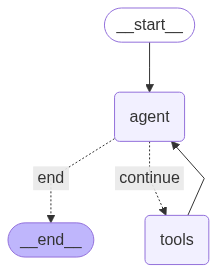

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

query = input("Enter your Escape.....")
while query != "exit":
    inputs = {"messages": [("user", query)]}

    print_stream(app.stream(inputs, stream_mode="values"))
    query = input("Enter your Escape.....")

================================ Human Message =================================

I wanna go to indore from gwalior on 7th aug 2025. Its just the 2 of us
================================== Ai Message ==================================
Tool Calls:
  get_flights_from_location (76c79756-9485-45d1-9493-dd53e1cdfaa8)
 Call ID: 76c79756-9485-45d1-9493-dd53e1cdfaa8
  Args:
    from_location: gwalior
    departDate: 2025-08-07
    adults: 2.0
    to_location: indore
================================= Tool Message =================================
Name: get_flights_from_location

{"messages": [], "flight_candidates": [{"token": "d6a1f_H4sIAAAAAAAA_0WQbW-yMBiFf41-o7QFeVnSLESQsYFoATf80iAg4txYaI08_PqnypKl7X2uc3o3bXoS4oc_qerx0jYnwZUrB00nuqYQNSi7L_XYy3Lous_2u1GLtlf99zBwKTSdzFexqshRPuXPdfHTgh4cifeRenTthCylwYZtaLAM1v68HoTC-5LM20MNCqLYtj0hLwlKfrEnBljkLwhR6DyishNEBwbdBpT6OfSmsCcvlhf58cNVJFrebvHo8Mjlejyu4njMYTzukyy7JNlnle_SrRmlAabJbYjO-1XoelqCtjxKq3C3vA1rKLJ7lrqOma0Cfl_ROeLR2Eh1eJh6M819XFaX8rUA6KaNHr4rONE